# ADNI HDF5 Preview

This notebook inspects the processed HDF5 dataset (3D volumes).

In [1]:
cd ..

/data_hdd_16t/duydang/reze/3D-Unet


In [2]:
from pathlib import Path
import h5py
import numpy as np

DATA_ROOT = Path('data/ADNI/hdf5')
SPLITS = ['train', 'val', 'test']

def list_h5(split):
    d = DATA_ROOT / split
    if not d.exists():
        return []
    return sorted([p for p in d.iterdir() if p.suffix == '.h5'])

In [3]:
for split in SPLITS:
    files = list_h5(split)
    print(f'{split}: {len(files)} files')

train: 1215 files
val: 136 files
test: 149 files


In [4]:
def inspect_file(path):
    with h5py.File(path, 'r') as f:
        raw_ds = f['raw']
        shape = raw_ds.shape
        dtype = raw_ds.dtype
        label = int(f['label'][()])
        attrs = dict(f.attrs)
    print('path:', path)
    print('shape:', shape, 'dtype:', dtype)
    print('label:', label)
    print('attrs:', attrs)

# Show one example from train if available
train_files = list_h5('train')
if train_files:
    inspect_file(train_files[0])
else:
    print('No train files found.')


path: data/ADNI/hdf5/train/train_ad_I102034.h5
shape: (160, 192, 192) dtype: float32
label: 1
attrs: {'label_raw': 'AD', 'normalize_mode': 'zscore', 'reorient_ras': 'True', 'source_csv': '/data_hdd_16t/duydang/reze/3D-Unet/data/ADNI/abb_9_13_2025.csv', 'source_key': 'abb', 'source_path': '/data_hdd_16t/duydang/reze/3D-Unet/data/ADNI/abb/ADNI/099_S_1144/MPR__GradWarp__B1_Correction__N3/2006-12-19_08_10_53.0/I102034/ADNI_099_S_1144_MR_MPR__GradWarp__B1_Correction__N3_Br_20080410140918798_S24219_I102034.nii', 'split': 'train', 'subject_id': '099_s_1144'}


In [5]:
def compute_stats(files, max_files=50):
    stats = []
    for path in files[:max_files]:
        with h5py.File(path, 'r') as f:
            raw = f['raw'][:]
            label = int(f['label'][()])
        stats.append((label, float(raw.min()), float(raw.max()), float(raw.mean()), float(raw.std())))
    return stats

files = list_h5('train')
if files:
    stats = compute_stats(files, max_files=20)
    labels = [s[0] for s in stats]
    print('labels:', labels)
    print('mean(min):', np.mean([s[1] for s in stats]))
    print('mean(max):', np.mean([s[2] for s in stats]))
    print('mean(mean):', np.mean([s[3] for s in stats]))
    print('mean(std):', np.mean([s[4] for s in stats]))
else:
    print('No train files found.')


labels: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
mean(min): -0.646173843741417
mean(max): 7.465295815467835
mean(mean): -4.601090020095455e-09
mean(std): 0.9999999970197677


In [6]:
# Quick label distribution
def label_hist(files, max_files=None):
    counts = {0: 0, 1: 0}
    for path in (files if max_files is None else files[:max_files]):
        with h5py.File(path, 'r') as f:
            label = int(f['label'][()])
        counts[label] = counts.get(label, 0) + 1
    return counts

for split in SPLITS:
    files = list_h5(split)
    if files:
        print(split, label_hist(files))
    else:
        print(split, 'no files')


train {0: 802, 1: 413}
val {0: 98, 1: 38}
test {0: 100, 1: 49}


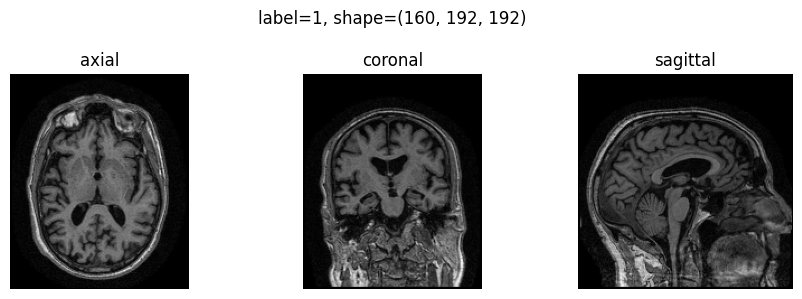

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def show_slices(path):
    with h5py.File(path, 'r') as f:
        vol = f['raw'][:]
        label = int(f['label'][()])
    # volume assumed (X, Y, Z)
    x = vol.shape[0] // 2
    y = vol.shape[1] // 2
    z = vol.shape[2] // 2
    axial = vol[:, :, z]
    coronal = vol[:, y, :]
    sagittal = vol[x, :, :]
    slices = [axial, coronal, sagittal]
    titles = ['axial', 'coronal', 'sagittal']
    plt.figure(figsize=(9, 3))
    for idx, (slc, title) in enumerate(zip(slices, titles), start=1):
        plt.subplot(1, 3, idx)
        plt.imshow(slc.T, cmap='gray', origin='lower')
        plt.title(title)
        plt.axis('off')
    plt.suptitle(f'label={label}, shape={vol.shape}')
    plt.tight_layout()
    plt.show()

files = list_h5('train')
if files:
    show_slices(files[0])
else:
    print('No train files found.')
